In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ML - реальные данные

In [2]:
gdf = gpd.read_parquet('data/blocks_indicator.parquet').to_crs(32636)
gdf.head()


,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Адаптируем статью

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Список типов землепользования
land_use_types = ['residential', 'recreation', 'special', 'industrial', 
                 'agriculture', 'transport', 'business', 'basic',
                 'residential_individual', 'residential_lowrise', 
                 'residential_midrise', 'residential_multistorey', 'mixed_use']

# Влияние типа землепользования на инвестиционную привлекательность
land_use_effect = {
    'residential': 0.7, 'recreation': 0.4, 'special': 0.3, 'industrial': 1.2,
    'agriculture': 0.5, 'transport': 0.8, 'business': 1.6, 'basic': 0.2,
    'residential_individual': 0.9, 'residential_lowrise': 1.0,
    'residential_midrise': 1.1, 'residential_multistorey': 1.3, 'mixed_use': 1.5
}

def calculate_investment_return(gdf, land_use_type, scaler=None):
    if land_use_type not in land_use_types:
        raise ValueError(f"land_use_type должен быть одним из: {land_use_types}")

    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")

    df_normalized = df.copy()
    numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df_normalized.columns if col not in numeric_cols]
    df_normalized = df_normalized.drop(columns=non_numeric_cols, errors='ignore')

    for col in df_normalized.columns:
        df_normalized[col] = pd.to_numeric(df_normalized[col], errors='coerce').fillna(0)

    id_columns = [col for col in df_normalized.columns if col.lower() in ['id', 'territory_id']]
    numeric_features = [col for col in df_normalized.columns if col not in id_columns and col != 'InvestmentReturn']
    
    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized[numeric_features] = scaler.fit_transform(df_normalized[numeric_features])
    else:
        scaler_features = scaler.feature_names_in_
        common_features = [f for f in numeric_features if f in scaler_features]
        df_normalized[common_features] = scaler.transform(df_normalized[common_features])

    base_investment_return = (
        # Демография и урбанизация (15% = 0.15)
        0.030 * df_normalized['Численность населения'] +
        0.030 * df_normalized['Степень урбанизации территории'] +
        0.030 * df_normalized['Плотность улично-дорожной сети'] +
        0.030 * df_normalized['Связанность населенных пунктов'] +
        0.030 * df_normalized['Обеспеченность общественными пространства'] +
        
        # Транспортная инфраструктура (25% = 0.25)
        0.021 * df_normalized['Протяженность дорог федерального значения'] +
        0.021 * df_normalized['Протяженность дорог регионального значения'] +
        0.021 * df_normalized['Протяженность дорог местного значения'] +
        0.021 * df_normalized['Количество маршрутов общественного транспорта'] +
        0.021 * df_normalized['Количество остановок общественного транспорта'] +
        0.021 * df_normalized['Общая протяженность железнодорожных путей'] +
        0.021 * df_normalized['Количество остановок железнодорожного транспорта'] +
        0.021 * (1 - df_normalized['Средняя доступность до федеральных транспортных магистралей']) +
        0.021 * (1 - df_normalized['Средняя доступность остановок железнодорожного транспорта']) +
        0.021 * df_normalized['Количество международных аэропортов'] +
        0.021 * df_normalized['Количество аэропортов местного значения'] +
        0.021 * df_normalized['Количество портов'] +
        
        # Социальная инфраструктура (25% = 0.25)
        0.018 * df_normalized['Обеспеченность детскими садами'] +
        0.018 * df_normalized['Обеспеченность школами'] +
        0.018 * df_normalized['Обеспеченность центрами детского творчества'] +
        0.018 * df_normalized['Обеспеченность школами искусств'] +
        0.018 * df_normalized['Обеспеченность ФАП / амбулаториями'] +
        0.018 * df_normalized['Обеспеченность аптеками'] +
        0.018 * df_normalized['Обеспеченность поликлиниками / центрами семейной медицины'] +
        0.018 * df_normalized['Обеспеченность участковыми больницами'] +
        0.018 * df_normalized['Обеспеченность городскими больницами (д/в)'] +
        0.018 * df_normalized['Обеспеченность детскими площадками'] +
        0.017 * df_normalized['Обеспеченность скверами / бульварами / лесопарками'] +
        0.017 * df_normalized['Обеспеченность парками'] +
        0.017 * df_normalized['Обеспеченность парками развлечений'] +
        0.017 * df_normalized['Социальное обеспечение (комфорт)'] +
        
        # Экономические факторы (20% = 0.20)
        0.020 * df_normalized['Обеспеченность продуктовыми магазинами'] +
        0.020 * df_normalized['Обеспеченность хозяйственными магазинами'] +
        0.020 * df_normalized['Обеспеченность ТЦ / супермаркетами'] +
        0.020 * df_normalized['Обеспеченность ТРК / гипермаркетами'] +
        0.020 * df_normalized['Обеспеченность профильными магазинами'] +
        0.020 * df_normalized['Обеспеченность кафе / кофейнями'] +
        0.020 * df_normalized['Обеспеченность барами / ресторанами'] +
        0.020 * df_normalized['Обеспеченность коммерческими клиниками'] +
        0.020 * df_normalized['Обеспеченность отделениями банков'] +
        0.020 * df_normalized['Количество автозаправочных станций'] +
        
        # Связанность и доступность (15% = 0.15)
        0.021 * df_normalized['Связанность'] +
        0.021 * (1 - df_normalized['Средняя доступность до центра региона']) +
        0.021 * (1 - df_normalized['Средняя доступность до федерального центра']) +
        0.021 * (1 - df_normalized['Средняя доступность до центра федерального округа']) +
        0.021 * df_normalized['Связанность общественным транспортом'] +
        0.021 * df_normalized['Количество объектов инженерной инфраструктуры'] +
        0.021 * df_normalized['Количество электростанций (ТЭС, АЭС и пр.)']
    )
    land_use_factor = land_use_effect[land_use_type]
    df['InvestmentReturn'] = base_investment_return * land_use_factor
    max_possible_value = 1.0 * max(land_use_effect.values())
    df['InvestmentReturn'] = df['InvestmentReturn'] / max_possible_value

    df['LandUseType'] = land_use_type
    return df

def prepare_for_training(gdf):
    if 'InvestmentReturn' not in gdf.columns:
        raise ValueError("В gdf отсутствует столбец InvestmentReturn.")
    if 'LandUseType' not in gdf.columns:
        raise ValueError("В gdf отсутствует столбец LandUseType.")

    df = gdf.copy()
    df = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')
    id_columns = [col for col in df.columns if col.lower() in ['id', 'territory_id']]
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df.columns if col not in numeric_cols and col not in id_columns and not col.startswith('LandUse')]
    df = df.drop(columns=non_numeric_cols, errors='ignore')
    df = df.drop(columns=['geometry'], errors='ignore')

    for col in df.columns:
        if col != 'InvestmentReturn':
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    scaler = MinMaxScaler()
    numeric_features = [col for col in df.columns if col not in id_columns and not col.startswith('LandUse') and col != 'InvestmentReturn']
    df[numeric_features] = scaler.fit_transform(df[numeric_features])

    for col in df.columns:
        if col.startswith('LandUse_'):
            df[col] = df[col].astype(int)

    df['Stratum'] = pd.qcut(df['InvestmentReturn'], q=4, labels=False, duplicates='drop')
    X = df.drop(['InvestmentReturn', 'Stratum'], axis=1)
    y = df['InvestmentReturn']

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y.values,
        train_size=0.75,
        stratify=df['Stratum'],
        random_state=42
    )

    X_columns = X.columns.tolist()
    dtypes = {col: 'float64' if col not in id_columns and not col.startswith('LandUse_') else 'int64' for col in X_columns}
    return X_train, X_test, y_train, y_test, scaler, X_columns, dtypes

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    nrmse_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min())
    nrmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    
    print("\nTraining Performance:")
    print(f"R²: {r2_train:.3f}")
    print(f"MAPE: {mape_train:.3f}")
    print(f"nRMSE: {nrmse_train:.3f}")
    
    print("\nTest Performance:")
    print(f"R²: {r2_test:.3f}")
    print(f"MAPE: {mape_test:.3f}")
    print(f"nRMSE: {nrmse_test:.3f}")
    
    return {
        'r2_train': r2_train, 'r2_test': r2_test,
        'mape_train': mape_train, 'mape_test': mape_test,
        'nrmse_train': nrmse_train, 'nrmse_test': nrmse_test
    }

Using all 82 features: ['id', 'territory_id', 'Численность населения', 'Степень урбанизации территории', 'Средняя доступность до федеральных транспортных магистралей', 'Средняя доступность до центра региона', 'Связанность', 'Связанность населенных пунктов', 'Плотность улично-дорожной сети', 'Протяженность дорог федерального значения', 'Протяженность дорог регионального значения', 'Протяженность дорог местного значения', 'Количество маршрутов общественного транспорта', 'Количество остановок общественного транспорта', 'Количество автозаправочных станций', 'Средняя доступность  автозаправочных станций', 'Общая протяженность железнодорожных путей', 'Количество остановок железнодорожного транспорта', 'Средняя доступность остановок железнодорожного транспорта', 'Количество международных аэропортов', 'Количество аэропортов местного значения', 'Средняя доступность международных аэропортов', 'Средняя доступность аэропортов местного значения', 'Количество портов', 'Обеспеченность детскими садами

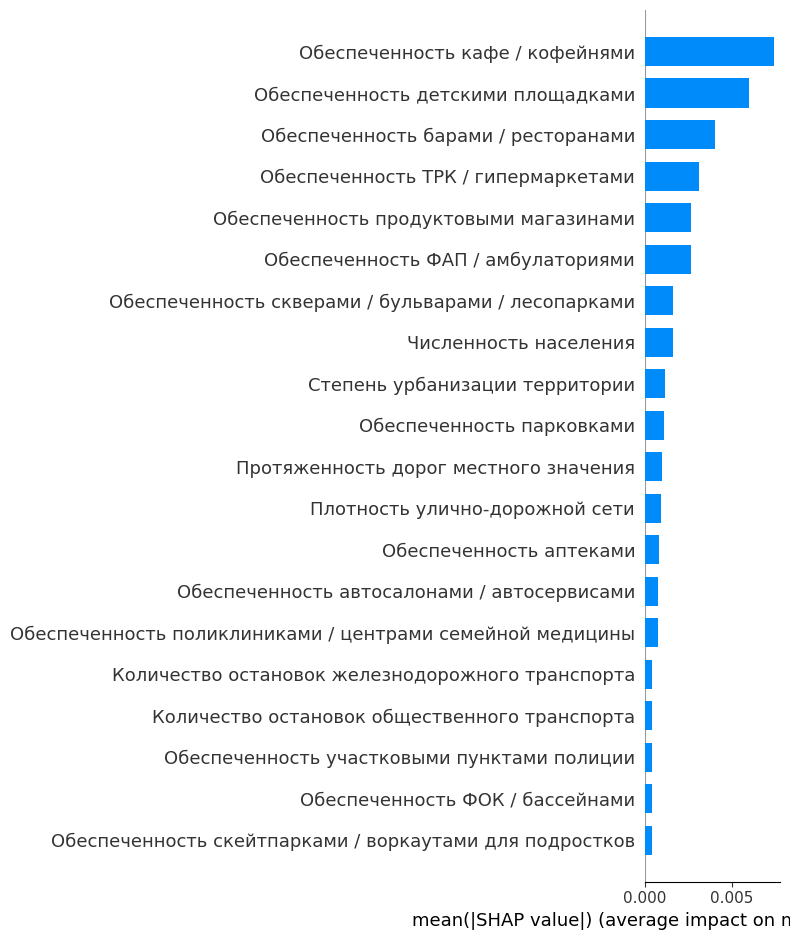


Generating SHAP Summary Plot (dot)...


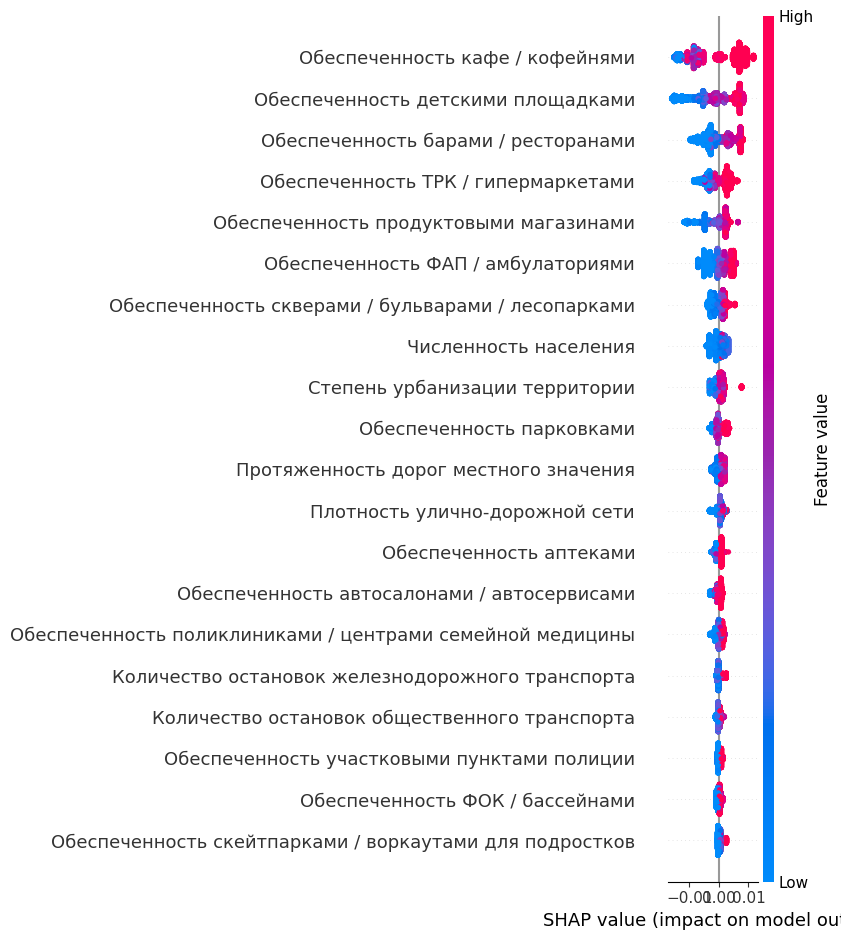


Generating SHAP Dependence Plot for Обеспеченность кафе / кофейнями...


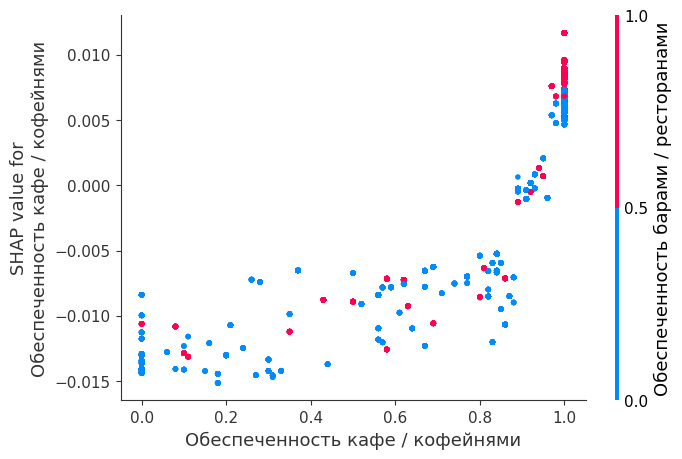


Generating SHAP Dependence Plot for Обеспеченность детскими площадками...


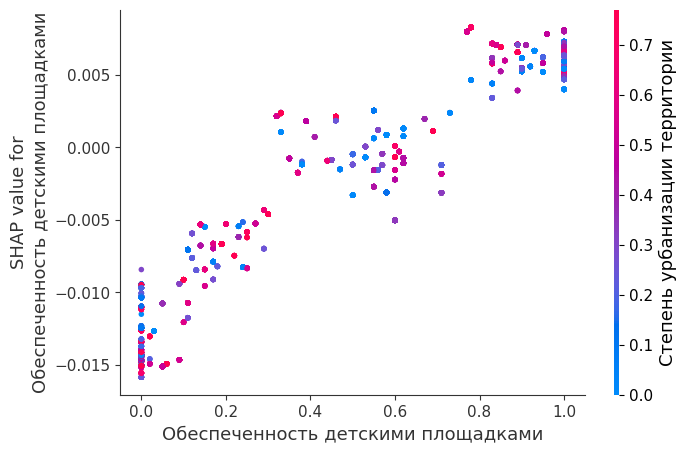


Generating SHAP Dependence Plot for Обеспеченность продуктовыми магазинами...


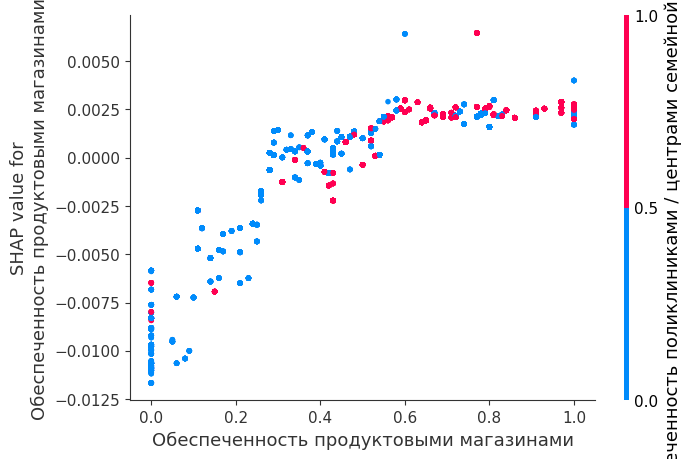


Baseline Model Performance:

Training Performance:
R²: 0.999
MAPE: 0.002
nRMSE: 0.004

Test Performance:
R²: 0.999
MAPE: 0.002
nRMSE: 0.004

Predicted InvestmentReturn for gdf_new: 0.154

Generating SHAP Waterfall Plot for gdf_new...


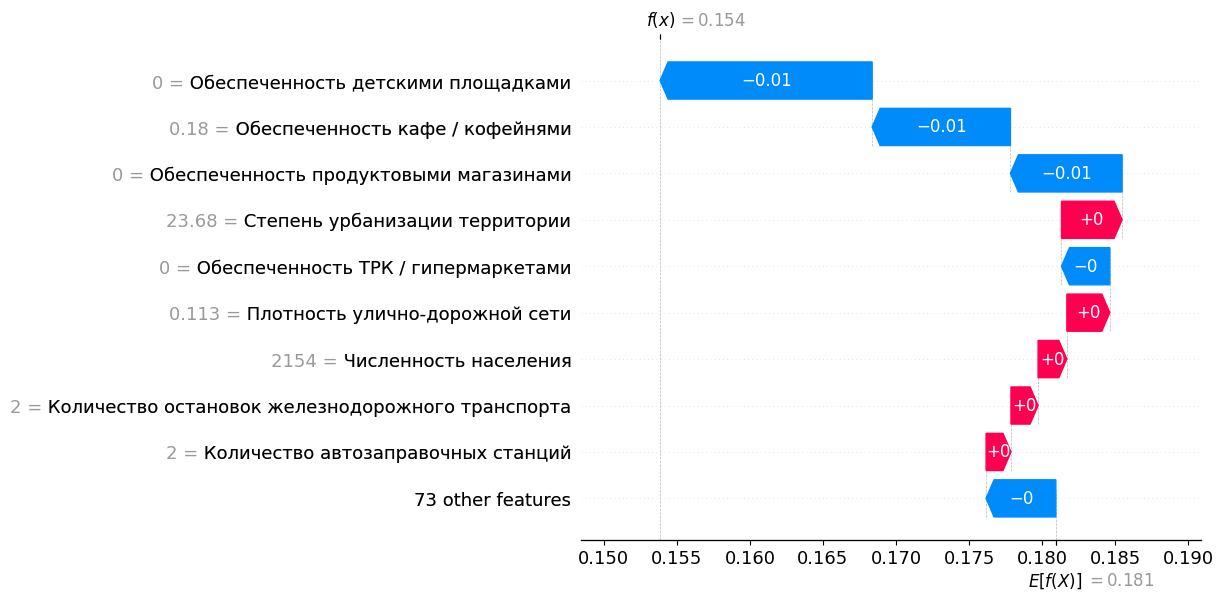

In [28]:
# Основной код обучения
df_with_returns = calculate_investment_return(gdf, 'transport')  # gdf - ваш исходный GeoDataFrame
X_train, X_test, y_train, y_test, scaler, X_columns, dtypes = prepare_for_training(df_with_returns)

# Преобразуем X_train и X_test обратно в DataFrame с правильными типами
X_train_df = pd.DataFrame(X_train, columns=X_columns).astype(dtypes)
X_test_df = pd.DataFrame(X_test, columns=X_columns).astype(dtypes)

# Очистка целевой переменной
y_train = pd.Series(y_train).replace([np.inf, -np.inf], np.nan).dropna()
y_test = pd.Series(y_test).replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.clip(lower=0, upper=1)
y_test = y_test.clip(lower=0, upper=1)

# Синхронизация индексов
X_train_df = X_train_df.loc[y_train.index]
X_test_df = X_test_df.loc[y_test.index]

# Используем все признаки
print(f"Using all {len(X_columns)} features: {X_columns}")

# Обучение модели с лучшими параметрами
best_params = {
    'alpha': 10.0,
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 4,
    'n_estimators': 300,
    'subsample': 1.0,
    'random_state': 42
}

best_model = XGBRegressor(**best_params)
best_model.fit(X_train_df, y_train)
print("Model trained with parameters:", best_params)

# Оценка модели
metrics = evaluate_model(best_model, X_train_df, X_test_df, y_train, y_test)

# Важность признаков (встроенная в XGBoost)
feature_importance = pd.DataFrame({
    'Feature': X_columns,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print("\nFeature Importance (XGBoost):")
print(feature_importance)

# SHAP-анализ
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

# 1. Summary Plot (общая важность признаков)
print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_df, plot_type="bar")
plt.show()

# 2. Summary Plot (распределение влияния признаков)
print("\nGenerating SHAP Summary Plot (dot)...")
shap.summary_plot(shap_values, X_test_df)
plt.show()

# 3. Dependence Plot для топ-3 признаков
top_features = feature_importance['Feature'].head(3).tolist()
for feature in top_features:
    print(f"\nGenerating SHAP Dependence Plot for {feature}...")
    shap.dependence_plot(feature, shap_values, X_test_df)
    plt.show()

# Сравнение с базовой моделью
base_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.3, alpha=1.0, random_state=42)
base_model.fit(X_train_df, y_train)
print("\nBaseline Model Performance:")
base_metrics = evaluate_model(base_model, X_train_df, X_test_df, y_train, y_test)

# Пример предсказания для gdf_new
gdf_new = gdf.iloc[[0]]
result = calculate_investment_return(gdf_new, 'residential', scaler)
X_new = pd.get_dummies(result.drop(columns=['InvestmentReturn', 'geometry'], errors='ignore'), columns=['LandUseType'], prefix='LandUse')
X_new = X_new.drop(columns=[col for col in X_new.columns if col.lower() in ['id', 'territory_id'] or col not in X_columns], errors='ignore')
for col in X_columns:
    if col not in X_new.columns:
        X_new[col] = 0
X_new = X_new[X_columns].astype(dtypes)
prediction = best_model.predict(X_new)
print(f"\nPredicted InvestmentReturn for gdf_new: {prediction[0]:.3f}")

# SHAP-анализ для gdf_new
shap_values_new = explainer.shap_values(X_new)
print("\nGenerating SHAP Waterfall Plot for gdf_new...")
shap.waterfall_plot(shap.Explanation(values=shap_values_new[0], 
                                     base_values=explainer.expected_value, 
                                     data=X_new.iloc[0], 
                                     feature_names=X_new.columns.tolist()))
plt.show()

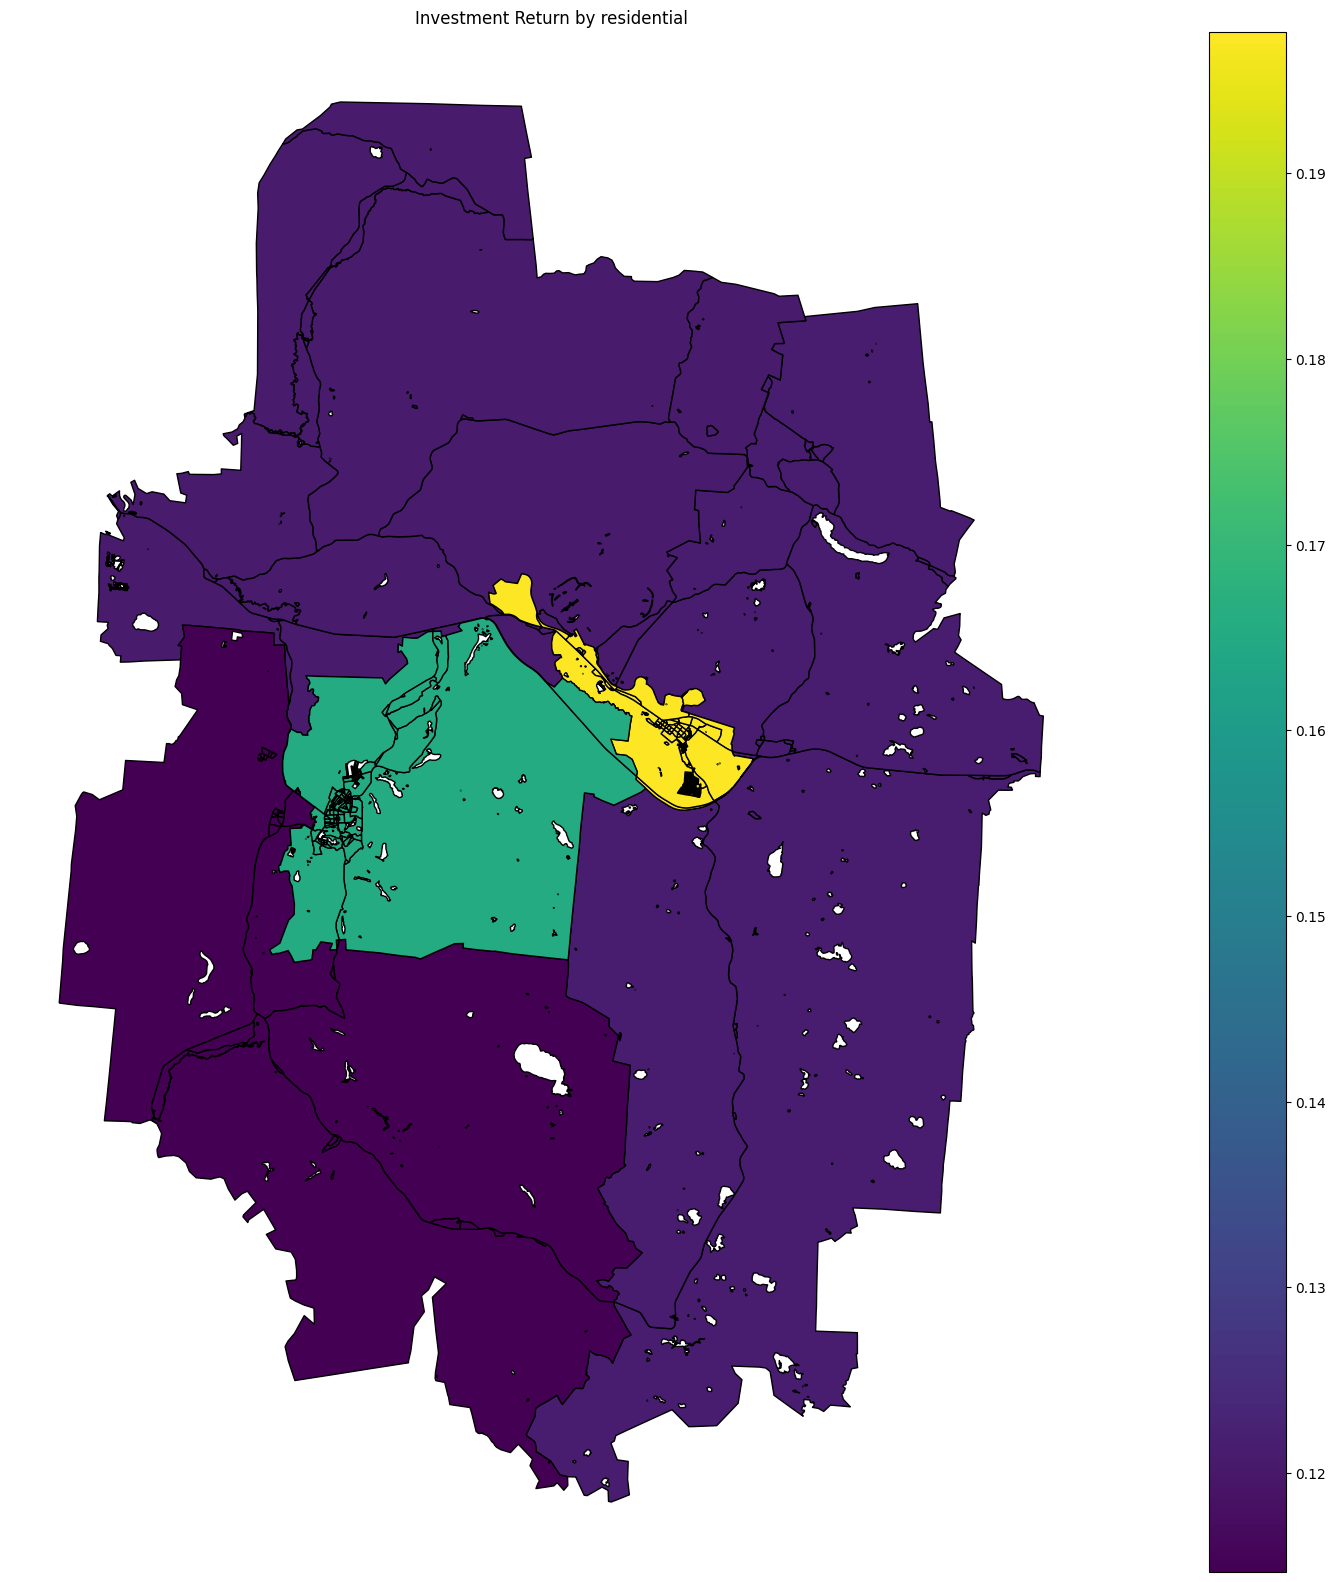

In [29]:

df_with_returns.head(500).plot(column='InvestmentReturn',
         cmap='viridis',           # или 'OrRd', 'coolwarm', 'plasma', см. ниже для других вариантов
         legend=True,
         edgecolor='black',
         figsize=(30, 20))
plt.title('Investment Return by residential')  # или другая подходящая подпись
plt.axis('off')
plt.show()

# Тест

In [76]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Константы
land_use_types = ['residential', 'recreation', 'special', 'industrial', 
                 'agriculture', 'transport', 'business', 'basic',
                 'residential_individual', 'residential_lowrise', 
                 'residential_midrise', 'residential_multistorey', 'mixed_use']

land_use_effect = {
    'residential': 0.7, 'recreation': 0.4, 'special': 0.3, 'industrial': 1.2,
    'agriculture': 0.5, 'transport': 0.8, 'business': 1.6, 'basic': 0.2,
    'residential_individual': 0.9, 'residential_lowrise': 1.0,
    'residential_midrise': 1.1, 'residential_multistorey': 1.3, 'mixed_use': 1.5
}

# Вспомогательная функция для нормализации и расчета базового значения
def _calculate_base_return(df, scaler=None):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_numeric = df[numeric_cols]
    
    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized = pd.DataFrame(scaler.fit_transform(df_numeric), 
                                   columns=df_numeric.columns, 
                                   index=df_numeric.index)
    else:
        df_normalized = pd.DataFrame(scaler.transform(df_numeric), 
                                   columns=df_numeric.columns, 
                                   index=df_numeric.index)
    
    base_return = (
        # Демография и урбанизация (15% = 0.15)
        0.030 * df_normalized['Численность населения'] +
        0.030 * df_normalized['Степень урбанизации территории'] +
        0.030 * df_normalized['Плотность улично-дорожной сети'] +
        0.030 * df_normalized['Связанность населенных пунктов'] +
        0.030 * df_normalized['Обеспеченность общественными пространства'] +
        
        # Транспортная инфраструктура (25% = 0.25)
        0.021 * df_normalized['Протяженность дорог федерального значения'] +
        0.021 * df_normalized['Протяженность дорог регионального значения'] +
        0.021 * df_normalized['Протяженность дорог местного значения'] +
        0.021 * df_normalized['Количество маршрутов общественного транспорта'] +
        0.021 * df_normalized['Количество остановок общественного транспорта'] +
        0.021 * df_normalized['Общая протяженность железнодорожных путей'] +
        0.021 * df_normalized['Количество остановок железнодорожного транспорта'] +
        0.021 * (1 - df_normalized['Средняя доступность до федеральных транспортных магистралей']) +
        0.021 * (1 - df_normalized['Средняя доступность остановок железнодорожного транспорта']) +
        0.021 * df_normalized['Количество международных аэропортов'] +
        0.021 * df_normalized['Количество аэропортов местного значения'] +
        0.021 * df_normalized['Количество портов'] +
        
        # Социальная инфраструктура (25% = 0.25)
        0.018 * df_normalized['Обеспеченность детскими садами'] +
        0.018 * df_normalized['Обеспеченность школами'] +
        0.018 * df_normalized['Обеспеченность центрами детского творчества'] +
        0.018 * df_normalized['Обеспеченность школами искусств'] +
        0.018 * df_normalized['Обеспеченность ФАП / амбулаториями'] +
        0.018 * df_normalized['Обеспеченность аптеками'] +
        0.018 * df_normalized['Обеспеченность поликлиниками / центрами семейной медицины'] +
        0.018 * df_normalized['Обеспеченность участковыми больницами'] +
        0.018 * df_normalized['Обеспеченность городскими больницами (д/в)'] +
        0.018 * df_normalized['Обеспеченность детскими площадками'] +
        0.017 * df_normalized['Обеспеченность скверами / бульварами / лесопарками'] +
        0.017 * df_normalized['Обеспеченность парками'] +
        0.017 * df_normalized['Обеспеченность парками развлечений'] +
        0.017 * df_normalized['Социальное обеспечение (комфорт)'] +
        
        # Экономические факторы (20% = 0.20)
        0.020 * df_normalized['Обеспеченность продуктовыми магазинами'] +
        0.020 * df_normalized['Обеспеченность хозяйственными магазинами'] +
        0.020 * df_normalized['Обеспеченность ТЦ / супермаркетами'] +
        0.020 * df_normalized['Обеспеченность ТРК / гипермаркетами'] +
        0.020 * df_normalized['Обеспеченность профильными магазинами'] +
        0.020 * df_normalized['Обеспеченность кафе / кофейнями'] +
        0.020 * df_normalized['Обеспеченность барами / ресторанами'] +
        0.020 * df_normalized['Обеспеченность коммерческими клиниками'] +
        0.020 * df_normalized['Обеспеченность отделениями банков'] +
        0.020 * df_normalized['Количество автозаправочных станций'] +
        
        # Связанность и доступность (15% = 0.15)
        0.021 * df_normalized['Связанность'] +
        0.021 * (1 - df_normalized['Средняя доступность до центра региона']) +
        0.021 * (1 - df_normalized['Средняя доступность до федерального центра']) +
        0.021 * (1 - df_normalized['Средняя доступность до центра федерального округа']) +
        0.021 * df_normalized['Связанность общественным транспортом'] +
        0.021 * df_normalized['Количество объектов инженерной инфраструктуры'] +
        0.021 * df_normalized['Количество электростанций (ТЭС, АЭС и пр.)']
    )
    
    return base_return, scaler

# 1. Отдельная функция для вычисления инвестиционной привлекательности
def calculate_investment_attractiveness(gdf, land_use_type, scaler=None):
    if land_use_type not in land_use_types:
        raise ValueError(f"land_use_type должен быть одним из: {land_use_types}")
    
    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")
    
    # Рассчитываем базовое значение и получаем scaler
    base_return, scaler = _calculate_base_return(df, scaler)
    
    # Применяем коэффициент для типа землепользования
    land_use_factor = land_use_effect[land_use_type]
    max_possible_value = 1.0 * max(land_use_effect.values())
    df['InvestmentReturn'] = (base_return * land_use_factor) / max_possible_value
    df['LandUseType'] = land_use_type
    
    return df, scaler

# 2. Оптимизированная функция создания обучающего набора данных
def create_training_dataframe(gdf, features):
    # Подготовка данных один раз
    df = gdf.drop_duplicates().fillna(0)
    
    # Рассчитываем базовое значение один раз
    base_return, scaler = _calculate_base_return(df)
    max_possible_value = 1.0 * max(land_use_effect.values())
    
    # Создание обучающего набора
    training_data = []
    for idx in df.index:
        for land_type in land_use_types:
            sample = {'LandUseType': land_type}
            for feature_name, feature_series in features.items():
                sample[feature_name] = feature_series.iloc[idx]
            
            # Рассчитываем InvestmentReturn
            land_use_factor = land_use_effect[land_type]
            sample['InvestmentReturn'] = (base_return.iloc[idx] * land_use_factor) / max_possible_value
            
            training_data.append(sample)
    
    # Создаем итоговый DataFrame
    training_df = pd.DataFrame(training_data)
    
    # Обработка числовых столбцов
    for col in training_df.columns:
        if col != 'LandUseType':
            training_df[col] = pd.to_numeric(training_df[col], errors='coerce')
            training_df[col] = training_df[col].replace([np.inf, -np.inf], np.nan)
            training_df[col] = training_df[col].fillna(training_df[col].median())
            training_df[col] = training_df[col].clip(lower=0, upper=1e6)
    
    return training_df
# 3. Функция подготовки данных для модели
def prepare_model_data(df):
    # Создаем копию DataFrame с one-hot encoding для LandUseType
    df_encoded = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')
    
    # Определяем столбцы ID для исключения (в любом регистре)
    id_columns = [col for col in df_encoded.columns if col.lower() in ['id', 'territory_id']]
    
    # Исключаем InvestmentReturn и ID-столбцы из признаков
    X = df_encoded.drop(columns=['InvestmentReturn'] + id_columns, axis=1)
    y = df_encoded['InvestmentReturn']
    
    # Нормализация признаков
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=0.75, random_state=42
    )
    
    return X_train, X_test, y_train, y_test, scaler, X.columns

# 4. Функция обучения модели
def train_model(X_train, y_train):
    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        alpha=10.0, colsample_bytree=0.8, subsample=1.0, random_state=42
    )
    model.fit(X_train, y_train)
    return model

# 5. Функция предсказания для одной территории
def predict_investment_attractiveness(gdf, model, scaler, feature_columns):
    df = gdf.drop(columns=['geometry'], errors='ignore')
    
    results = []
    for land_type in land_use_types:
        sample = pd.DataFrame(columns=feature_columns)
        for col in feature_columns:
            if col.startswith('LandUse_'):
                sample[col] = [1 if col == f'LandUse_{land_type}' else 0]
            elif col in df.columns:
                sample[col] = df[col].iloc[0]
            else:
                sample[col] = 0
        
        X_scaled = scaler.transform(sample)
        prediction = model.predict(X_scaled)[0]
        results.append({
            'LandUseType': land_type,
            'InvestmentReturn': prediction
        })
    
    return pd.DataFrame(results)

def get_model_statistics(model, X_train, X_test, y_train, y_test, feature_columns, gdf=None, scaler=None):
    # Базовые метрики
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    stats = {
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_test': r2_score(y_test, y_test_pred),
        'mape_train': mean_absolute_percentage_error(y_train, y_train_pred),
        'mape_test': mean_absolute_percentage_error(y_test, y_test_pred),
        'nrmse_train': np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min()),
        'nrmse_test': np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    }
    
    # Преобразуем X_test в DataFrame для SHAP
    X_test_df = pd.DataFrame(X_test, columns=feature_columns)
    
    # SHAP-анализ
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_df)
    
    # 1. Summary Plot (общая важность признаков)
    print("\nGenerating SHAP Summary Plot (bar)...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df, plot_type="bar")
    plt.title("SHAP Summary Plot (Bar)")
    plt.show()
    
    # 2. Summary Plot (распределение влияния признаков)
    print("\nGenerating SHAP Summary Plot (dot)...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df)
    plt.title("SHAP Summary Plot (Dot)")
    plt.show()
    
    # Важность признаков для выбора топ-3
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # 3. Dependence Plot для топ-3 признаков
    top_features = feature_importance['Feature'].head(3).tolist()
    for feature in top_features:
        print(f"\nGenerating SHAP Dependence Plot for {feature}...")
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feature, shap_values, X_test_df)
        plt.title(f"SHAP Dependence Plot for {feature}")
        plt.show()
    
    # Сравнение с базовой моделью
    base_model = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.3, 
        alpha=1.0, random_state=42
    )
    base_model.fit(X_train, y_train)
    print("\nBaseline Model Performance:")
    base_y_train_pred = base_model.predict(X_train)
    base_y_test_pred = base_model.predict(X_test)
    base_stats = {
        'r2_train': r2_score(y_train, base_y_train_pred),
        'r2_test': r2_score(y_test, base_y_test_pred),
        'mape_train': mean_absolute_percentage_error(y_train, base_y_train_pred),
        'mape_test': mean_absolute_percentage_error(y_test, base_y_test_pred),
        'nrmse_train': np.sqrt(np.mean((y_train - base_y_train_pred) ** 2)) / (y_train.max() - y_train.min()),
        'nrmse_test': np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    }
    for metric, value in base_stats.items():
        print(f"{metric}: {value:.3f}")
    
    # Пример предсказания и SHAP для новой территории (если передан gdf)
    if gdf is not None and scaler is not None:
        gdf_new = gdf.iloc[[0]]
        result, _ = calculate_investment_attractiveness(gdf_new, 'residential', scaler)
        
        # Удаляем ненужные столбцы и добавляем one-hot encoding
        id_columns = [col for col in result.columns if col.lower() in ['id', 'territory_id']]
        X_new = result.drop(columns=['InvestmentReturn', 'geometry'] + id_columns, errors='ignore')
        X_new = pd.get_dummies(X_new, columns=['LandUseType'], prefix='LandUse')
        
        # Приводим к тому же набору столбцов, что в feature_columns
        for col in feature_columns:
            if col not in X_new.columns:
                X_new[col] = 0
        X_new = X_new[feature_columns]  # Оставляем только нужные столбцы в правильном порядке
        
        # Преобразуем с помощью scaler
        X_new_scaled = scaler.transform(X_new)
        
        # Предсказание
        prediction = model.predict(X_new_scaled)
        print(f"\nPredicted InvestmentReturn for gdf_new: {prediction[0]:.3f}")
        
        # SHAP-анализ для gdf_new
        shap_values_new = explainer.shap_values(X_new)
        print("\nGenerating SHAP Waterfall Plot for gdf_new...")
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap.Explanation(
            values=shap_values_new[0],
            base_values=explainer.expected_value,
            data=X_new.iloc[0],
            feature_names=X_new.columns.tolist()
        ))
        plt.title("SHAP Waterfall Plot for New Prediction")
        plt.show()
    
    return stats, base_stats, feature_importance


In [77]:
base_df, base_scaler = calculate_investment_attractiveness(gdf, 'residential')
print("Базовая привлекательность:\n", base_df[['InvestmentReturn', 'LandUseType']].head())

Базовая привлекательность:
    InvestmentReturn  LandUseType
0          0.106077  residential
1          0.106077  residential
2          0.106077  residential
3          0.106077  residential
4          0.106077  residential


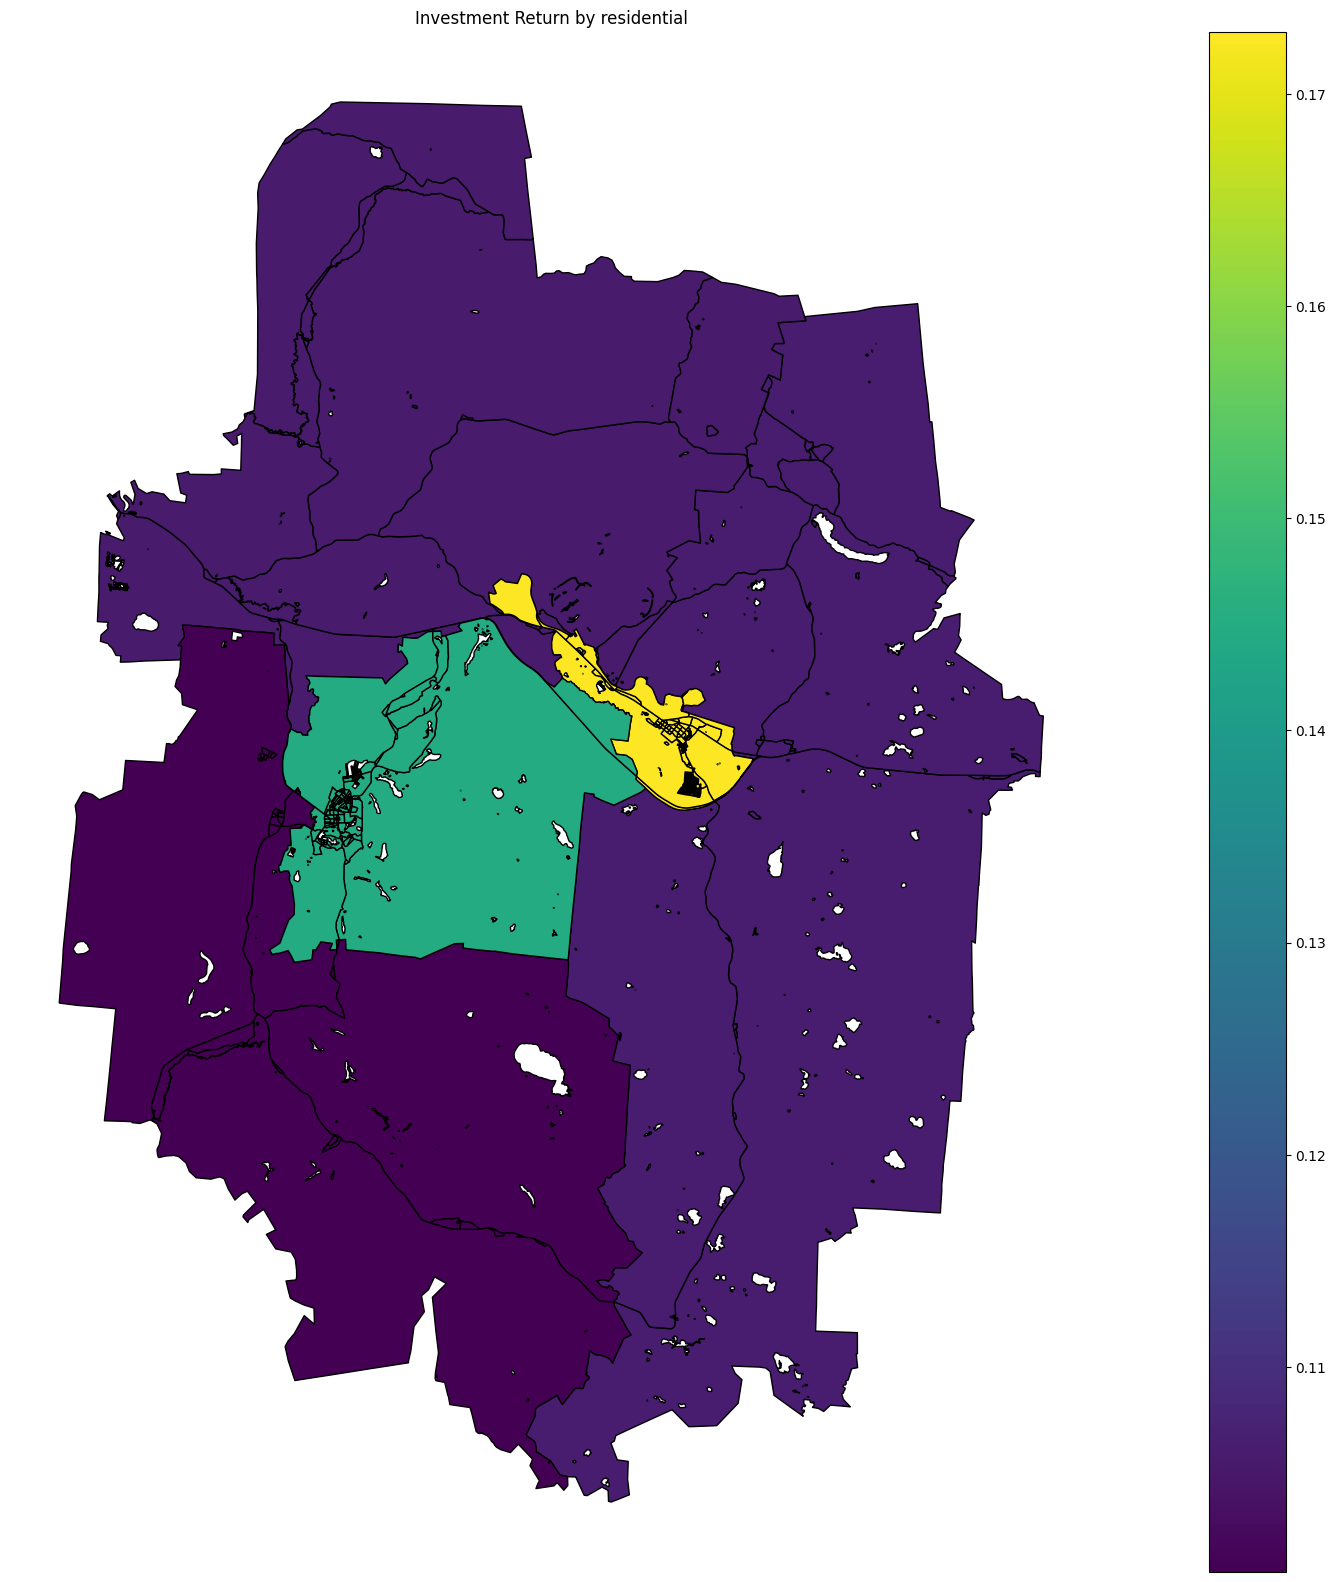

In [78]:

base_df.head(500).plot(column='InvestmentReturn',
         cmap='viridis',           # или 'OrRd', 'coolwarm', 'plasma', см. ниже для других вариантов
         legend=True,
         edgecolor='black',
         figsize=(30, 20))
plt.title('Investment Return by residential')  # или другая подходящая подпись
plt.axis('off')
plt.show()

In [80]:
features = {col: gdf[col] for col in gdf.columns if col != 'geometry'}
training_df = create_training_dataframe(gdf, features)
training_df.head()

,LandUseType,id,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций,InvestmentReturn
0,residential,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.106077
1,recreation,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.060615
2,special,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.045461
3,industrial,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.181846
4,agriculture,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.075769



Предсказания для новой территории:
                 LandUseType  InvestmentReturn
0               residential          0.224271
1                recreation          0.140054
2                   special          0.100176
3                industrial          0.344932
4               agriculture          0.163965
5                 transport          0.252122
6                  business          0.445232
7                     basic          0.074453
8    residential_individual          0.270020
9       residential_lowrise          0.289177
10      residential_midrise          0.321485
11  residential_multistorey          0.374475
12                mixed_use          0.440092

Generating SHAP Summary Plot (bar)...


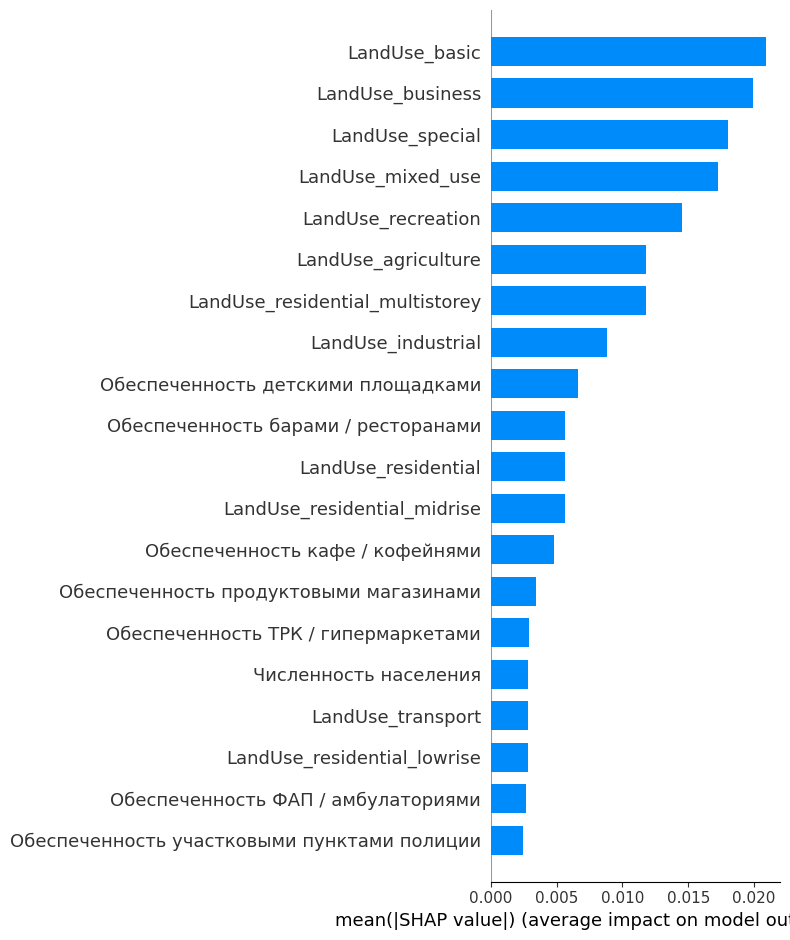

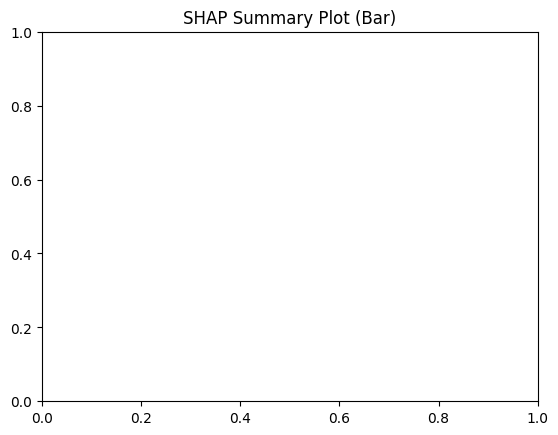


Generating SHAP Summary Plot (dot)...


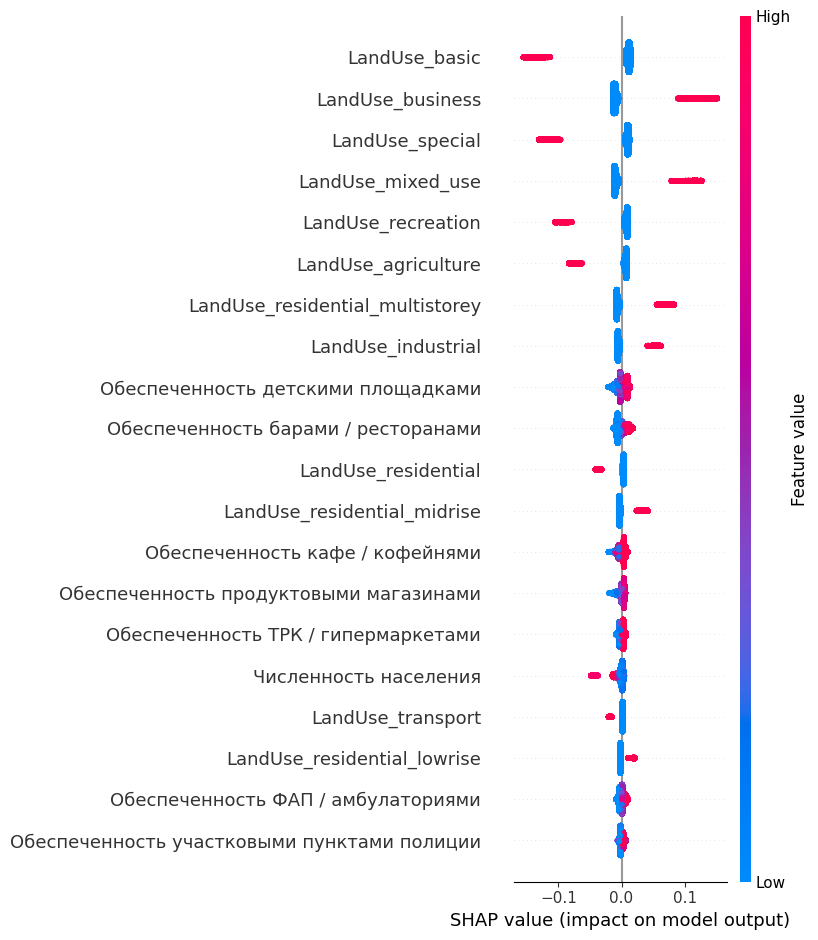

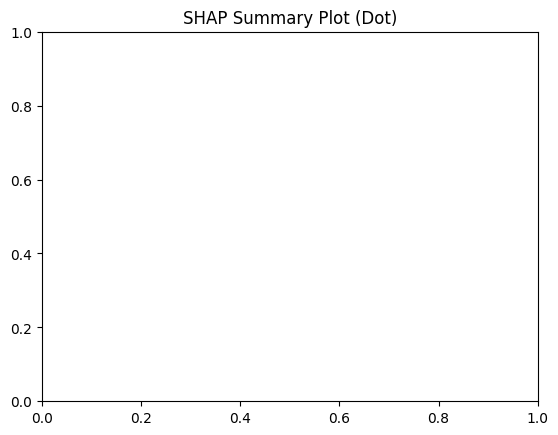


Generating SHAP Dependence Plot for LandUse_mixed_use...


<Figure size 1000x600 with 0 Axes>

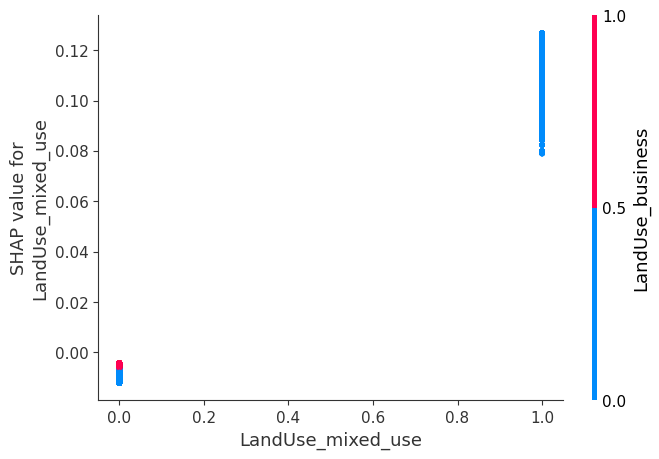

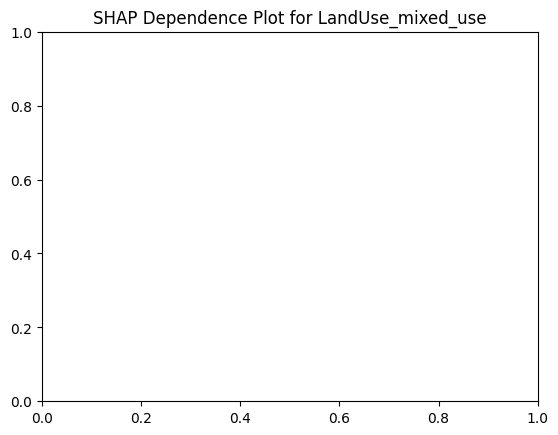


Generating SHAP Dependence Plot for LandUse_business...


<Figure size 1000x600 with 0 Axes>

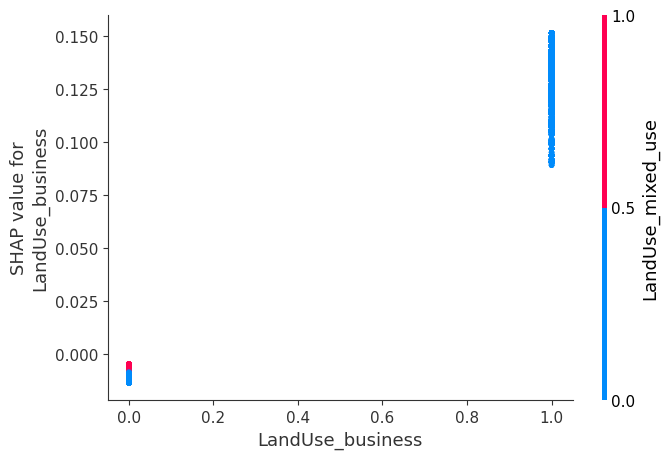

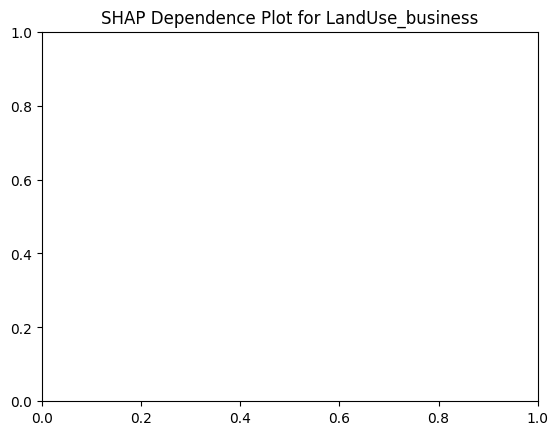


Generating SHAP Dependence Plot for LandUse_residential_multistorey...


<Figure size 1000x600 with 0 Axes>

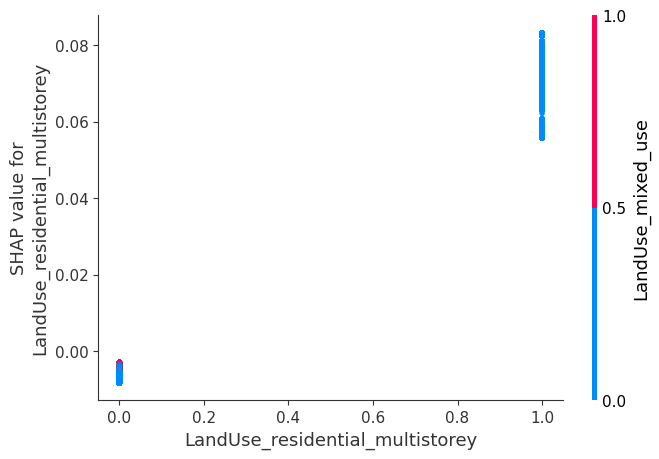

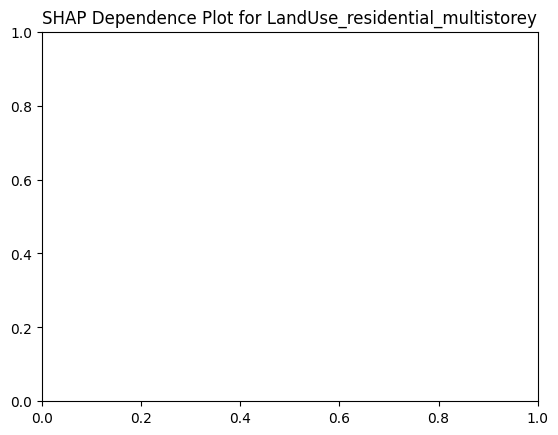


Baseline Model Performance:
r2_train: 1.000
r2_test: 1.000
mape_train: 0.005
mape_test: 0.006
nrmse_train: 0.003
nrmse_test: 0.010


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- id
- territory_id
Feature names seen at fit time, yet now missing:
- LandUse_agriculture
- LandUse_basic
- LandUse_business
- LandUse_industrial
- LandUse_mixed_use
- ...


In [81]:
# 3. Подготовка данных для модели
X_train, X_test, y_train, y_test, scaler, feature_columns = prepare_model_data(training_df)

# 4. Обучение модели
model = train_model(X_train, y_train)

# 5. Предсказание для новой территории
gdf_new = gdf.iloc[[0]]
predictions = predict_investment_attractiveness(gdf_new, model, scaler, feature_columns)
print("\nПредсказания для новой территории:\n", predictions)

# 6. Получение статистики
# Получение статистики
stats, base_stats, feature_importance = get_model_statistics(
    model, X_train, X_test, y_train, y_test, feature_columns, gdf, scaler
)


# Версия 2


In [8]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"
import requests

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{335}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{335}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf

,geometry,Средняя этажность,Численность населения,Плотность населения,Площадь территории,Оценка по каркасу расселения,Население,Экологическая ситуация,Потенциал размещения порта,Социальное обеспечение,...,Потенциал развития жилой застройки типа ИЖС,Потенциал развития малоэтажной жилой застройки,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки общественно-деловой зоны,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки транспортной зоны
0,"MULTIPOLYGON (((329788.882 6583309.434, 330250...",2.0,0.0,0.0,789.4,5.0,4.0,-1.91,2.01,3.6,...,2.0,3.0,3.0,1.0,2.0,4.0,5.0,4.0,3.0,5.0


In [9]:
list(polygon_gdf.columns)


['geometry',
 'Средняя этажность',
 'Численность населения',
 'Плотность населения',
 'Площадь территории',
 'Оценка по каркасу расселения',
 'Население',
 'Экологическая ситуация',
 'Потенциал размещения порта',
 'Социальное обеспечение',
 'Количество аэропортов местного значения',
 'Средняя доступность аэропортов местного значения',
 'Транспортное обеспечение',
 'Земли водного фонда',
 'Земли лесных массивов',
 'Количество международных аэропортов',
 'Земли специального назначения',
 'Доступность водных объектов',
 'Земли жилой застройки',
 'Земли рекреационного назначения',
 'Земли промышленного назначения',
 'Земли зелёных насаждений',
 'Земли сельскохозяйственного назначения',
 'Количество автозаправочных станций',
 'Средняя доступность остановок железнодорожного транспорта',
 'Социальное обеспечение (комфорт)',
 'Средняя доступность до близлежайшего крупного населенного пункта',
 'Общая протяженность железнодорожных путей',
 'Количество портов',
 'Количество маршрутов общественно

In [26]:


# 5. Список типов землепользования
land_use_types = [
    'residential', 'recreation', 'special', 'industrial', 
    'agriculture', 'transport', 'business', 'basic',
    'residential_individual', 'residential_lowrise', 
    'residential_midrise', 'residential_multistorey', 'mixed_use'
]

# 6. Коэффициенты влияния на привлекательность
land_use_effect = {
    'residential': 0.7, 'recreation': 0.4, 'special': 0.3, 'industrial': 1.2,
    'agriculture': 0.5, 'transport': 0.8, 'business': 1.6, 'basic': 0.2,
    'residential_individual': 0.9, 'residential_lowrise': 1.0,
    'residential_midrise': 1.1, 'residential_multistorey': 1.3, 'mixed_use': 1.5
}

# 7. Ключевые индикаторы для оценки (можешь подправить по смыслу)
investment_factors = [
    'Плотность населения',
    'Социальное обеспечение',
    'Транспортное обеспечение',
    'Обеспечение инженерной инфраструктурой',
    'Оценка по транспортному каркасу',
    'Оценка по экологическому каркасу'
]

# Проверка наличия всех факторов
for factor in investment_factors:
    if factor not in polygon_gdf.columns:
        raise Exception(f"Индикатор '{factor}' не найден в GeoDataFrame")

# Получаем значения напрямую
factor_values = polygon_gdf[investment_factors].iloc[0].values
# Заполняем NaN нулями (если вдруг есть)
factor_values = [v if v is not None else 0 for v in factor_values]
base_score = sum(factor_values)


# 10. Рассчитываем привлекательность для каждого типа землепользования
investment_scores = {
    land_type: round(base_score * multiplier, 3)
    for land_type, multiplier in land_use_effect.items()
}

# 11. Сортируем по убыванию
investment_scores = dict(sorted(investment_scores.items(), key=lambda x: x[1], reverse=True))

# 12. Вывод
print("\nИнвестиционная привлекательность по типам землепользования:\n")
for land_type, score in investment_scores.items():
    print(f"{land_type:30} — {score}")




Инвестиционная привлекательность по типам землепользования:

business                       — 27.36
mixed_use                      — 25.65
residential_multistorey        — 22.23
industrial                     — 20.52
residential_midrise            — 18.81
residential_lowrise            — 17.1
residential_individual         — 15.39
transport                      — 13.68
residential                    — 11.97
agriculture                    — 8.55
recreation                     — 6.84
special                        — 5.13
basic                          — 3.42
